In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
zip_path = "/content/drive/MyDrive/newsData.zip"

In [6]:
import zipfile
import os

extract_path = "/content/newsData"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully")
print(os.listdir(extract_path))

Files extracted successfully
['raw_analyst_ratings.csv']


In [7]:
import pandas as pd

file_path = "/content/newsData/raw_analyst_ratings.csv"

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [8]:
!pip install ta yfinance pynance

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.3 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=3ec00039eac2ce2c156952dede7462e9129dceab43f2c2a6352334a121c2af93
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [9]:
import yfinance as yf

stock_df = yf.download("AAPL", start="2020-01-01", end="2024-12-31")

/tmp/ipykernel_5870/1259831363.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download("AAPL", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [10]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    utc=True
).dt.date

In [11]:
df["date"].head()

,date
0,2020-06-05
1,2020-06-03
2,2020-05-26
3,2020-05-22
4,2020-05-22


In [12]:
df["date"] = pd.to_datetime(df["date"]).dt.date

In [13]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


,0
Unnamed: 0,0
headline,0
url,0
publisher,0
date,0
stock,0


In [12]:
stock_df.reset_index(inplace=True)

stock_df["Date"] = pd.to_datetime(stock_df["Date"]).dt.date

In [13]:
# Convert stock dates to pandas datetime
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

# Convert news dates too
df["date"] = pd.to_datetime(df["date"])

# Create sorted trading dates
trading_dates = stock_df["Date"].sort_values()

# Align each news date to nearest future trading day
df["aligned_date"] = trading_dates.searchsorted(df["date"])

# Replace index positions with actual trading dates
df["aligned_date"] = df["aligned_date"].apply(
    lambda x: trading_dates.iloc[x]
    if x < len(trading_dates)
    else pd.NaT
)

In [14]:
df[["date", "aligned_date"]].head()

,date,aligned_date
0,2020-06-05,2020-06-05
1,2020-06-03,2020-06-03
2,2020-05-26,2020-05-26
3,2020-05-22,2020-05-22
4,2020-05-22,2020-05-22


In [15]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [16]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df["sentiment"] = df["headline"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

In [18]:
stock_df["Daily_Return"] = (
    stock_df["Close"].pct_change() * 100
)

In [20]:
daily_sentiment = (
    df.groupby(["aligned_date", "stock"])["sentiment"]
    .mean()
    .reset_index()
)

In [22]:
stock_df.columns = stock_df.columns.get_level_values(0)

In [23]:
stock_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return'], dtype='object', name='Price')

In [24]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on="aligned_date",
    right_on="Date",
    how="inner"
)

In [25]:
correlation = merged_df["sentiment"].corr(
    merged_df["Daily_Return"]
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.20877577005109355


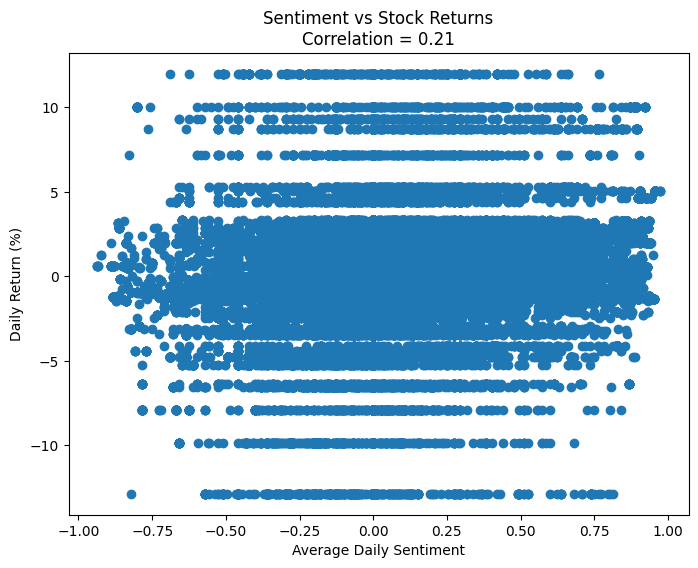

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["sentiment"],
    merged_df["Daily_Return"]
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.title(
    f"Sentiment vs Stock Returns\nCorrelation = {correlation:.2f}"
)

plt.show()

In [29]:
def classify_sentiment(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    else:
        return "Neutral"

merged_df["Sentiment_Category"] = merged_df["sentiment"].apply(
    classify_sentiment
)

In [30]:
category_returns = (
    merged_df.groupby("Sentiment_Category")["Daily_Return"]
    .mean()
)

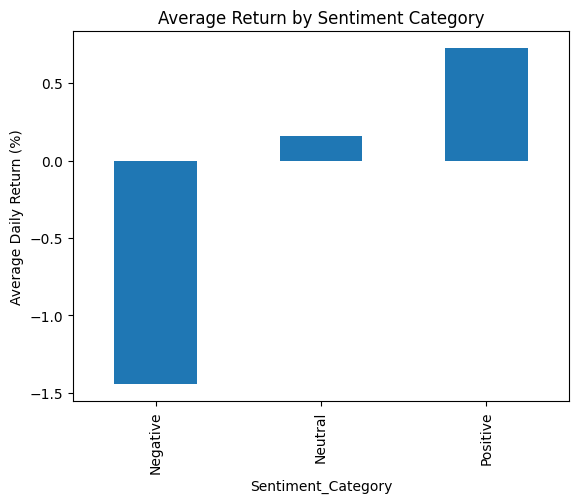

In [31]:
category_returns.plot(kind="bar")

plt.ylabel("Average Daily Return (%)")
plt.title("Average Return by Sentiment Category")

plt.show()